*****************Breast Cancer Wisconsin (Diagnostic) Dataset*****************





In [ ]:
# import Libarares
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve,
                             confusion_matrix)

##Step 1: ****Data Preprocessing****

---



● Load both datasets.

In [ ]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
x,y=data.data,data.target
df=pd.DataFrame(x,columns=data.feature_names)
df['target']=y
print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

● Handle missing values appropriately.

In [ ]:
df=df.dropna() #Handle missing values

● Normalize or standardize numerical features if required.

In [ ]:
scaler = StandardScaler()
x_scaler = scaler.fit_transform(df)


● Split each dataset into training and testing sets (e.g., 70% train, 30% test).

In [ ]:
x_train, x_test,y_train,y_test = train_test_split(x, y, test_size=0.3, random_state=42)

##Step 2: ****Model Building****

---

● Train a Logistic Regression model on each dataset.

In [ ]:
model_logistic=LogisticRegression(max_iter=10000)
model_logistic.fit(x_train,y_train)

LogisticRegression(max_iter=10000)

● Train a Naive Bayes model on each dataset using different Naive Bayes variants and
justify your choice (consider GaussianNB for numeric).

In [ ]:
# GaussianNB: suitable because my data has numeric features
model_gnb = GaussianNB()
model_gnb.fit(x_train, y_train)


GaussianNB()

##Step 3: ****Model Evaluation and Visualization****

● Predict outcomes on the test sets.

In [ ]:
y_pred_logreg=model_logistic.predict(x_test)
y_pred_gnb=model_gnb.predict(x_test)

● Compute and report the following metrics for both models on each dataset:
○ Accuracy
○ Precision
○ Recall
○ F1-Score
○ ROC-AUC Score

In [ ]:

y_prob_logreg =model_logistic.predict_proba(x_test)[:,1]  # probabilities for ROC
y_prob_gnb = model_gnb.predict_proba(x_test)[:,1]

In [ ]:
def print_metrics(y_true,y_pred,y_prob,model_name):
  print(f"---{model_name}---")
  print("Accuracy:",accuracy_score(y_true,y_pred))
  print("Precision:",precision_score(y_true,y_pred))
  print("Recall:",recall_score(y_true,y_pred))
  print("F1-Score:",f1_score(y_true,y_pred))
  print("ROC-AUC Score:",roc_auc_score(y_true,y_prob))
  print()


print_metrics(y_test, y_pred_logreg, y_prob_logreg, "Logistic Regression")
print_metrics(y_test, y_pred_gnb, y_prob_gnb, "GaussianNB")

---Logistic Regression---
Accuracy: 0.9766081871345029
Precision: 0.9814814814814815
Recall: 0.9814814814814815
F1-Score: 0.9814814814814815
ROC-AUC Score: 0.9976484420928865

---GaussianNB---
Accuracy: 0.9415204678362573
Precision: 0.9454545454545454
Recall: 0.9629629629629629
F1-Score: 0.9541284403669725
ROC-AUC Score: 0.9922104644326867



● Plot ROC curves for both models on each dataset, overlaying them for direct
comparison.

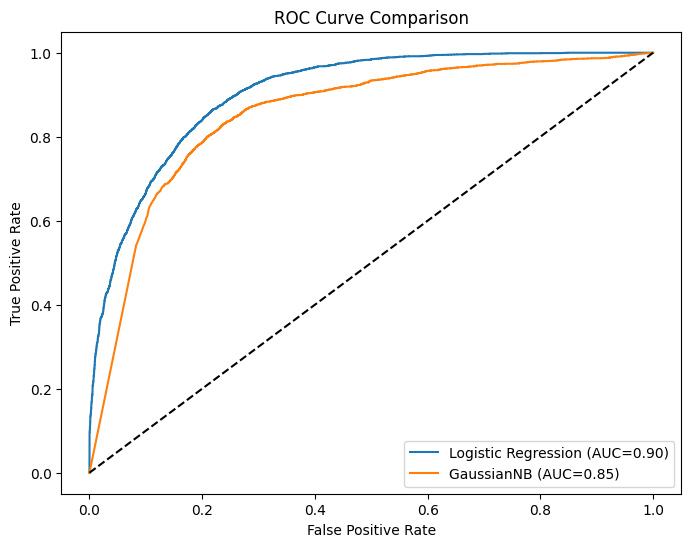

In [ ]:

#False Positive Rate & True Positive Rate
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_prob_logreg)
fpr_gnb, tpr_gnb, _ = roc_curve(y_test, y_prob_gnb)

# ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr_logreg, tpr_logreg, label=f'Logistic Regression (AUC={roc_auc_score(y_test, y_prob_logreg):.2f})')
plt.plot(fpr_gnb, tpr_gnb, label=f'GaussianNB (AUC={roc_auc_score(y_test, y_prob_gnb):.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()


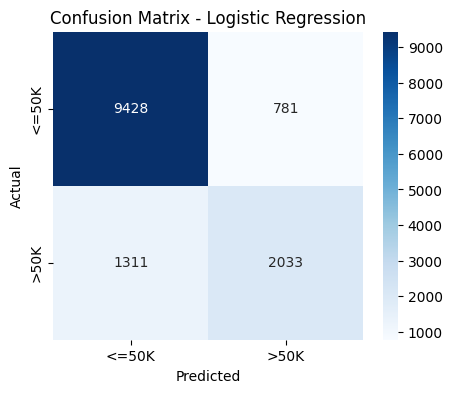

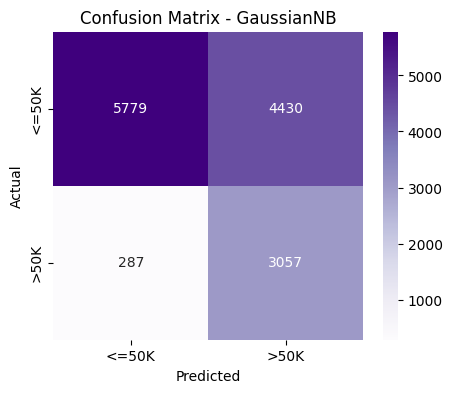

In [ ]:


# Confusion Matrix for Logistic Regression
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
plt.figure(figsize=(5,4))
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues', xticklabels=target_le.classes_, yticklabels=target_le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

# Confusion Matrix for GaussianNB
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
plt.figure(figsize=(5,4))
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Purples', xticklabels=target_le.classes_, yticklabels=target_le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - GaussianNB')
plt.show()
